In [103]:
import numpy as np 
import matplotlib.pyplot as plt 
import pandas as pd 
import seaborn as sns
import random
import math
import scipy.stats as stats

# Problem 1

In [32]:
def create_grid(k):
    klist = []
    for i in range(1, k+1):
        klist.append((float)(i/k))
    return klist

def draw_point(grid):
    size = len(grid)
    index = random.randrange(0, size)
    return grid[index]

def create_df(grid, n):
    df = pd.DataFrame(columns=["value"], dtype=np.float64)
    for i in range(n):
        df.loc[i, "value"] = draw_point(grid)
    return df



In [47]:
grid = create_grid(500)
draw_point(grid)
df = create_df(grid, 5_000)
df

,value
0,0.180
1,0.188
2,0.054
3,0.344
4,0.376
...,...
4995,0.638
4996,0.034
4997,0.838
4998,0.760


<Axes: xlabel='value', ylabel='Proportion'>

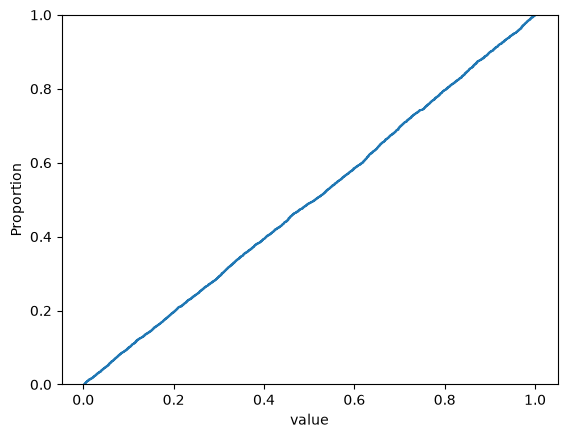

In [102]:
sns.ecdfplot(data=df, x='value')


**This approaches a uniform(0,1) distribution as K increases. This is because the values are more dense across (0,1) as k increases, which forms a more and more linear appearing line.**

# Problem 2

In [ ]:
#Uniform[-sqrt(3), sqrt(3)]
def get_mean(n=32):
    grid2 = np.array([], dtype=np.float64)
    for i in range(n):
        grid2 = np.append(grid2, [random.uniform(-math.sqrt(3), math.sqrt(3))])
    return grid2.mean() *np.sqrt(n)


grid2 = np.array([], dtype=np.float64)
for i in range(5_000):
    grid2 = np.append(grid2, [get_mean()])
grid2


array([-0.50380851, -0.98247837,  1.61861626, ...,  0.51828073,
       -0.72196051, -0.54031961], shape=(5000,))

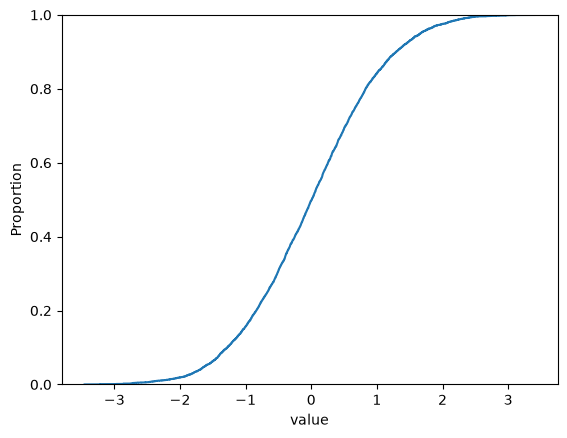

In [ ]:
df2 = pd.DataFrame(data=grid2, columns=['value'], dtype=np.float64)
df2
sns.ecdfplot(data=df2, x='value', label='n=32')


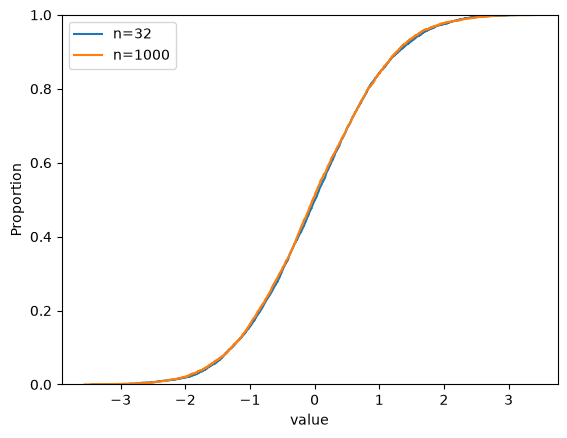

In [175]:
grid2_p = np.array([], dtype=np.float64)
for i in range(5_000):
    grid2_p = np.append(grid2_p, [get_mean(n=1000)])

df2_p = pd.DataFrame(data=grid2_p, columns=['value'], dtype=np.float64)

sns.ecdfplot(data=df2, x='value', label='n=32')
sns.ecdfplot(data=df2_p, x='value', label='n=1000')

plt.legend()
plt.show()

**As N increases from 32 -> 1000, the ECDF for this simulation approaches a standard normal distribution even more.**

# Problem 3

In [159]:
def flip_coins(n=40, p=0.5):
    heads = np.random.binomial(n, p)
    return (heads-(n*p)) / (math.sqrt( n * p * (1-p) ))

values = []
for i in range(5_000):
    values.append(flip_coins(n=40, p=0.5))
df3 = pd.DataFrame({'value': values})
    

<Axes: xlabel='value', ylabel='Proportion'>

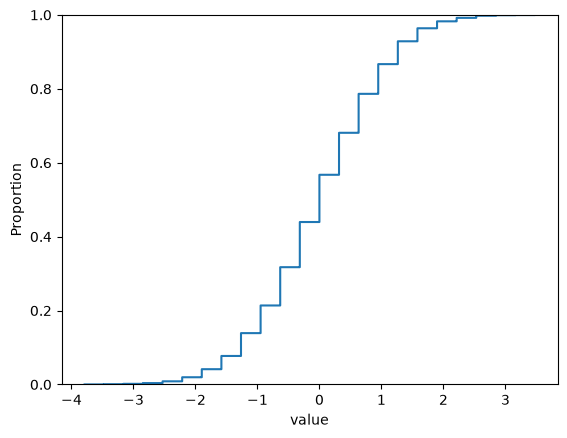

In [160]:
sns.ecdfplot(data=df3, x='value')

<Axes: xlabel='value', ylabel='Proportion'>

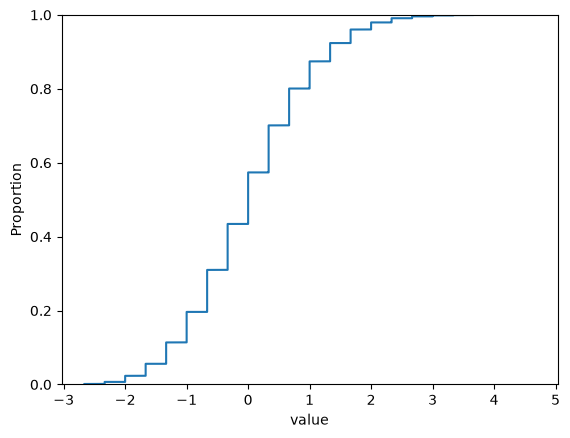

In [161]:
values2 = []
for i in range(5_000):
    values2.append(flip_coins(n=100, p=0.1))
dfh2 = pd.DataFrame({'value': values2})

sns.ecdfplot(data=dfh2, x='value')

<Axes: xlabel='value', ylabel='Proportion'>

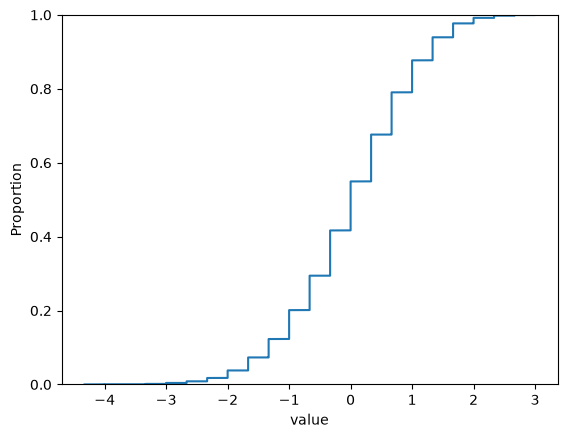

In [163]:
values3 = []
for i in range(5_000):
    values3.append(flip_coins(n=100, p=0.9))
dfh3 = pd.DataFrame({'value': values3})

sns.ecdfplot(data=dfh3, x='value')

**This simulation also approaches a standard normal distribution as N increases. Increasing and decreasing p to 0.9 and 0.1 changed the actual binomial distribution, but the simulations still exhibited a standard normal distribution.**

# Problem 5

In [166]:
def get_ranked_val(K=20, rank = 19):
    list = []
    for i in range(K):
        list.append(random.uniform(0,1))
    list.sort()
    return list[rank]

def plot_ecdf(rank, K=20, n=5_000):
    list = []
    for i in range(n):
        list.append(get_ranked_val(K, rank))
    df4 = pd.DataFrame({'value': list})
    sns.ecdfplot(data=df4, x='value')


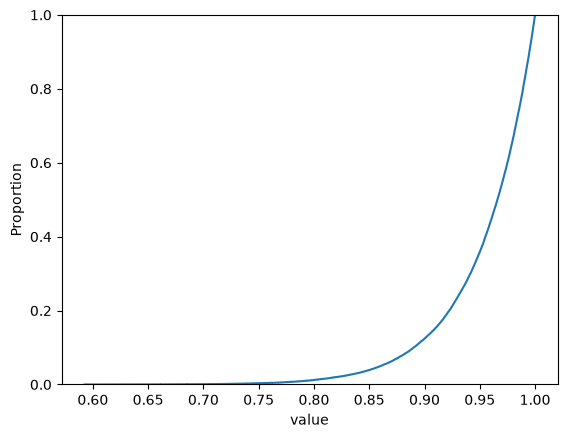

In [167]:
plot_ecdf(19, K=20, n=50_000)

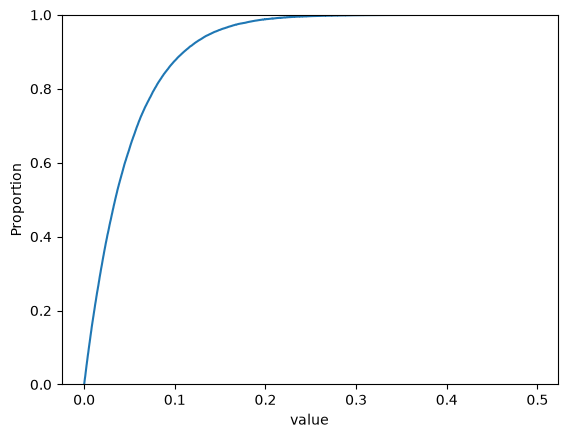

In [168]:
plot_ecdf(0, K=20, n=50_000)

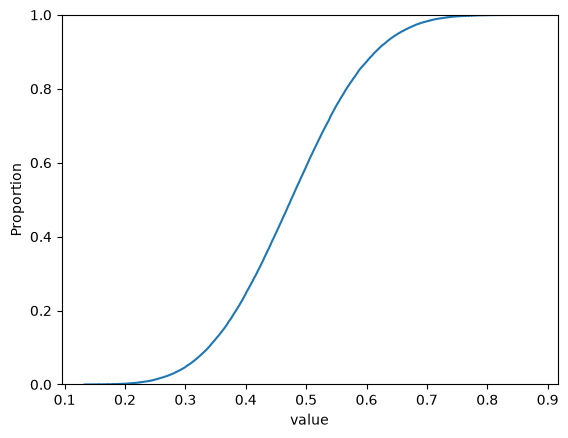

In [169]:
plot_ecdf(9, K=20, n=50_000)

**The ranked values from this simulation approach a beta distribution. As seen in the ECDFs, the higher rank ECDF is concentrated near 1, the middle ECDF near 0.5, and the low rank near 0. The ECDF distribution is reliant on the simulation rank.**